<a href="https://colab.research.google.com/github/eshaans1305/AI-LAB/blob/main/1BM24CS096_ZOMATO_delivery_route_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter the number of orders to simulate: 10

Starting Genetic Algorithm Route Optimization for 10 orders...

Generation 001: Minimum Route Distance = 93.97 km
Generation 020: Minimum Route Distance = 64.88 km
Generation 040: Minimum Route Distance = 55.33 km
Generation 060: Minimum Route Distance = 55.33 km
Generation 080: Minimum Route Distance = 55.33 km
Generation 100: Minimum Route Distance = 55.33 km
Generation 120: Minimum Route Distance = 55.33 km
Generation 140: Minimum Route Distance = 55.33 km
Generation 160: Minimum Route Distance = 55.33 km
Generation 180: Minimum Route Distance = 55.33 km
Generation 200: Minimum Route Distance = 55.33 km

================ METRICS & RESULTS ================
Optimized Route Chain:
Hub (0) -> Rest(5) -> Rest(3) -> Rest(4) -> Rest(1) -> Rest(8) -> Cust(1) -> Rest(7) -> Rest(2) -> Cust(8) -> Rest(9) -> Cust(5) -> Rest(10) -> Cust(4) -> Rest(6) -> Cust(9) -> Cust(7) -> Cust(2) -> Cust(3) -> Cust(10) -> Cust(6) -> Hub (0)
Final Minimum Driving Dis

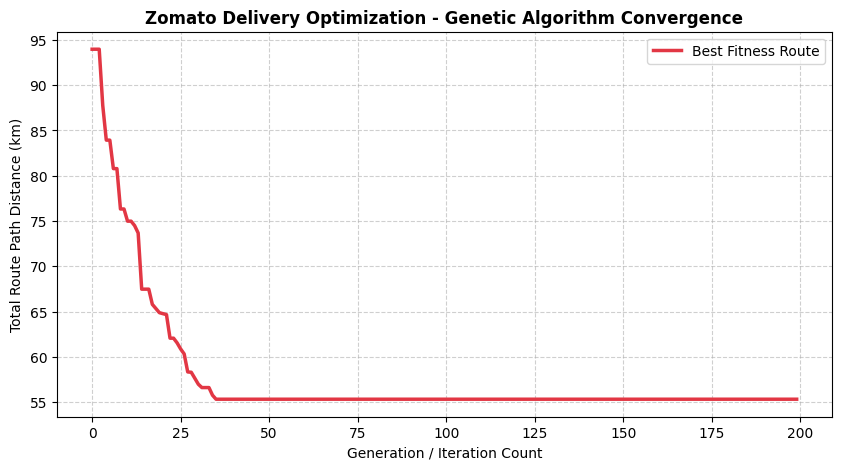

5

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random


NUM_ORDERS = int(input("Enter the number of orders to simulate: "))

POP_SIZE = 100
GENERATIONS = 200
MUTATION_RATE = 0.15
CROSSOVER_RATE = 0.8
PENALTY_VALUE = 999999  # Penalty distance for invalid precedence routes

# Node IDs:
# 0: Zomato Hub / Delivery Executive Start
# 1 to NUM_ORDERS: Restaurant IDs
# NUM_ORDERS+1 to 2*NUM_ORDERS: Customer IDs (Order i pickup is 'i', delivery is 'i + NUM_ORDERS')

np.random.seed(42)  # For reproducible results
random.seed(42)

# Generate random (x, y) coordinates for all locations in a 10km x 10km grid based on user input size
coordinates = np.random.uniform(0, 10, size=(2 * NUM_ORDERS + 1, 2))

# Calculate a distance matrix using Euclidean distance
def calculate_distance_matrix(coords):
    num_nodes = len(coords)
    matrix = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            matrix[i][j] = np.linalg.norm(coords[i] - coords[j])
    return matrix

distance_matrix = calculate_distance_matrix(coordinates)

# ==========================================
# 2. HELPER FUNCTIONS FOR GENETIC ALGORITHM
# ==========================================

def create_valid_individual():
    """Generates a random valid delivery sequence that respects precedence rules."""
    elements = list(range(1, 2 * NUM_ORDERS + 1))
    # Keep shuffling until a naturally valid sequence is found for the initial population
    while True:
        random.shuffle(elements)
        if is_valid_route(elements):
            return elements

def is_valid_route(route):
    """Checks if every restaurant pickup occurs before its customer delivery."""
    for i in range(1, NUM_ORDERS + 1):
        restaurant_idx = route.index(i)
        customer_idx = route.index(i + NUM_ORDERS)
        if customer_idx < restaurant_idx:
            return False
    return True

def compute_fitness(individual):
    """Calculates path distance. Appends a heavy penalty if invalid."""
    # Complete route starts at Hub (0), hits the sequence, and returns to Hub (0)
    full_route = [0] + individual + [0]

    # Strict Precedence Constraint Checking
    if not is_valid_route(individual):
        return 1.0 / PENALTY_VALUE  # Return extremely low fitness

    total_dist = 0.0
    for i in range(len(full_route) - 1):
        total_dist += distance_matrix[full_route[i]][full_route[i+1]]

    return 1.0 / total_dist  # Minimize distance by maximizing inverse fitness

def tournament_selection(pop, fitnesses, k=3):
    """Selects the best individual out of k randomly chosen candidates."""
    selected_indices = random.sample(range(len(pop)), k)
    best_index = max(selected_indices, key=lambda idx: fitnesses[idx])
    return pop[best_index].copy()

def ordered_crossover(parent1, parent2):
    """Applies Ordered Crossover (OX) for valid permutation pathways."""
    if random.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()

    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))

    def fill_offspring(p1, p2):
        child = [None] * size
        # Copy matching genetic slice from first parent
        child[start:end+1] = p1[start:end+1]

        # Fill remaining slots using elements from second parent while keeping relative order
        p2_pointer = 0
        for i in range(size):
            if child[i] is None:
                while p2[p2_pointer] in child:
                    p2_pointer += 1
                child[i] = p2[p2_pointer]
        return child

    return fill_offspring(parent1, parent2), fill_offspring(parent2, parent1)

def mutate(individual):
    """Swaps two random locations in the path sequence based on mutation probability."""
    if random.random() < MUTATION_RATE:
        idx1, idx2 = random.sample(range(len(individual)), 2)
        individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
    return individual

# ==========================================
# 3. CORE EVOLUTIONARY LOOP
# ==========================================

# Step 1: Initialize Population
population = [create_valid_individual() for _ in range(POP_SIZE)]
history_best_distance = []

print(f"\nStarting Genetic Algorithm Route Optimization for {NUM_ORDERS} orders...\n")

# Step 2: Iterate generations
for gen in range(GENERATIONS):
    fitness_scores = [compute_fitness(ind) for ind in population]

    # Track the generation's absolute best setup
    best_idx = np.argmax(fitness_scores)
    best_distance = 1.0 / fitness_scores[best_idx] if fitness_scores[best_idx] > 0 else PENALTY_VALUE
    history_best_distance.append(best_distance)

    if (gen + 1) % 20 == 0 or gen == 0:
        print(f"Generation {gen+1:03d}: Minimum Route Distance = {best_distance:.2f} km")

    # Generate the next generation matching system limits
    new_population = []

    # Elitism: Automatically carry forward the absolute best route
    new_population.append(population[best_idx].copy())

    while len(new_population) < POP_SIZE:
        # Selection
        p1 = tournament_selection(population, fitness_scores)
        p2 = tournament_selection(population, fitness_scores)

        # Crossover
        c1, c2 = ordered_crossover(p1, p2)

        # Mutation
        c1 = mutate(c1)
        c2 = mutate(c2)

        new_population.extend([c1, c2])

    # Trim array if trailing loops generated overflow entries
    population = new_population[:POP_SIZE]

# Final Evaluation
final_fitnesses = [compute_fitness(ind) for ind in population]
best_final_idx = np.argmax(final_fitnesses)
optimized_sequence = population[best_final_idx]
optimized_distance = 1.0 / final_fitnesses[best_final_idx]

# Format clean layout string display
clean_route = "Hub (0) -> " + " -> ".join(
    f"Rest({node})" if node <= NUM_ORDERS else f"Cust({node - NUM_ORDERS})" for node in optimized_sequence
) + " -> Hub (0)"

print("\n================ METRICS & RESULTS ================")
print(f"Optimized Route Chain:\n{clean_route}")
print(f"Final Minimum Driving Distance: {optimized_distance:.2f} km")

# ==========================================
# 4. DATA VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(history_best_distance, color='#E23744', linewidth=2.5, label='Best Fitness Route') # Zomato Red Color
plt.title('Zomato Delivery Optimization - Genetic Algorithm Convergence', fontsize=12, fontweight='bold')
plt.xlabel('Generation / Iteration Count', fontsize=10)
plt.ylabel('Total Route Path Distance (km)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()
5
